In [1]:
from libra_toolbox.neutron_detection.activation_foils import compass
from libra_toolbox.neutron_detection.activation_foils.calibration import ba133, cs137, co60, na22, mn54
import matplotlib.pyplot as plt
import numpy as np
import json
import datetime
from pathlib import Path
from libra_toolbox.neutron_detection.activation_foils.calibration import CheckSource, Nuclide

In [2]:
def create_nuclide_spectrum(
    nuclide: Nuclide,
    signal_to_background_ratio: float,
    peak_standard_deviation: float,
    background_detector: compass.Detector,
    background_divider: float = 1.0,
):
    # In case background has many events, scale it down to speed up test
    background_hist = background_detector._spectrum / background_divider

    total_counts_background = np.sum(background_hist)
    desired_signal_counts = signal_to_background_ratio * total_counts_background

    nuclide_events = np.zeros((0,))
    for energy, intensity in zip(nuclide.energy, nuclide.intensity):
        compton_fraction = 0.1  # ~20% of events go to Compton scattering
        # Full energy peak
        nuclide_events = np.append(
            nuclide_events,
            np.random.normal(
                loc=energy,
                scale=peak_standard_deviation,
                size=int(desired_signal_counts * intensity * (1 - compton_fraction)),
            ),
        )

        # Compton edge
        compton_edge = energy * (1 - 1 / (1 + (2 * energy / 511)))
        compton_events = int(desired_signal_counts * intensity * compton_fraction)

        # Generate Compton events below the edge with a smooth falloff
        # Using exponential distribution peaked near the edge
        compton_samples = np.random.exponential(
            scale=compton_edge / 3, size=compton_events
        )
        # Shift to be centered below the edge
        compton_samples = compton_edge - np.abs(compton_samples)
        compton_samples = compton_samples[
            compton_samples > 0
        ]  # Remove negative energies
        nuclide_events = np.append(nuclide_events, compton_samples)
    nuclide_hist, _ = np.histogram(
        nuclide_events, bins=background_detector._calibrated_bin_edges
    )

    noise_level = 1.0
    gaussian_noise = np.random.normal(
        0, noise_level * np.sqrt(nuclide_hist), size=nuclide_hist.shape
    )

    overall_hist = nuclide_hist + background_hist + gaussian_noise
    return overall_hist


In [ ]:
def test_get_peaks(detector_type, nuclide, signal_to_background_ratio):

    # get real background measurement
    background_measurements = compass.Measurement.from_h5(
         "compass_test_data/background_measurement/background_measurements.h5"
    )

    # read in calibration coefficients from json
    with open(
         "compass_test_data/background_measurement/calibration_coefficients.json", "r"
    ) as f:
        calibration_coefficients = json.load(f)

    if detector_type == "NaI":
        coeffs = calibration_coefficients["NaI"]["4"]
        peak_standard_deviation = 30.0  # keV
        background_divider = 100.0
        for background_measurement in background_measurements:
            if background_measurement.name == "NaI Background":
                background_detector = background_measurement.get_detector(4)
                break
    elif detector_type == "HPGe":
        coeffs = calibration_coefficients["HPGe"]["0"]
        peak_standard_deviation = 2.0  # keV
        background_divider = 1.0
        for background_measurement in background_measurements:
            if background_measurement.name == "HPGe Background":
                background_detector = background_measurement.get_detector(0)
                break
    else:
        raise ValueError(f"Unknown detector type: {detector_type}")

    background_detector._calibrated_bin_edges = np.polyval(
        coeffs, background_detector._bin_edges
    )

    # Build simulated spectrum with nuclide peaks + background
    overall_hist = create_nuclide_spectrum(
        nuclide=nuclide,
        signal_to_background_ratio=signal_to_background_ratio,
        peak_standard_deviation=peak_standard_deviation,
        background_detector=background_detector,
        background_divider=background_divider,
    )

    fig, ax = plt.subplots()
    ax.stairs(overall_hist, background_detector._calibrated_bin_edges, label="Simulated Spectrum")
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Counts")
    ax.vlines(background_detector._calibrated_bin_edges[400], 
              0, np.max(overall_hist), 
              colors='lightgray', linestyles='dotted', linewidth=0.5)
    ax.set_title(nuclide.name)
    if detector_type == "NaI":
        ax.set_yscale("log")
    ax.grid()

    # Create a check source measurement instance
    check_source_detector = compass.Detector(channel_nb=0)
    check_source_detector._spectrum = overall_hist
    check_source_detector._bin_edges = background_detector._calibrated_bin_edges

    check_source = CheckSource(nuclide=nuclide,
                               activity_date=datetime.datetime(2024, 1, 1),
                               activity=1.0)
    
    check_source_meas = compass.CheckSourceMeasurement('test')
    check_source_meas.check_source = check_source
    check_source_meas.detectors = [check_source_detector]
    check_source_meas.detector_type = detector_type

    test_peak_inds = check_source_meas.get_peaks(overall_hist)
    test_peaks = background_detector._calibrated_bin_edges[
        test_peak_inds
    ]
    if len(test_peaks) != len(nuclide.energy):
        print(f"test_peak length: {len(test_peaks)}", f"nuclide energy length: {len(nuclide.energy)}")
        print(f"Detected peaks at: {test_peaks}")
    # assert len(test_peaks) == len(nuclide.energy)
    for test_energy, expected_energy in zip(test_peaks, nuclide.energy):
        if not np.isclose(test_energy, expected_energy, rtol=0.05):
            print(f"Detected peak at {test_energy:.2f} keV, expected at {expected_energy} keV")
        # assert np.isclose(test_energy, expected_energy, rtol=0.05)


Testing NaI with Co60 at S/B=1.0

Testing NaI with Cs137 at S/B=10.0

Testing NaI with Mn54 at S/B=0.01

Testing NaI with Na22 at S/B=10.0

Testing NaI with Na22 at S/B=0.1

Testing HPGe with Ba133 at S/B=1.0

Testing HPGe with Co60 at S/B=1.0

Testing HPGe with Cs137 at S/B=10.0

Testing HPGe with Mn54 at S/B=0.01

Testing HPGe with Na22 at S/B=10.0

Testing HPGe with Na22 at S/B=0.1


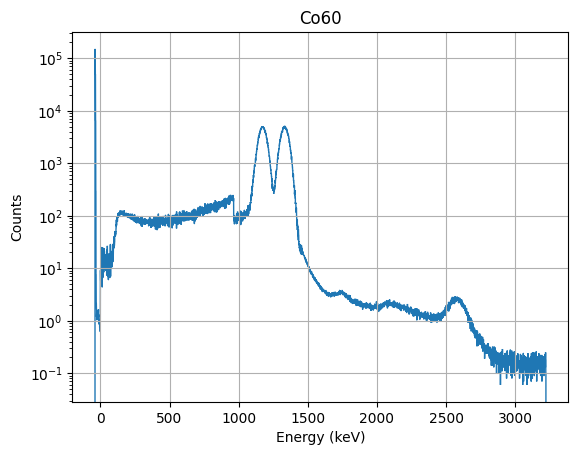

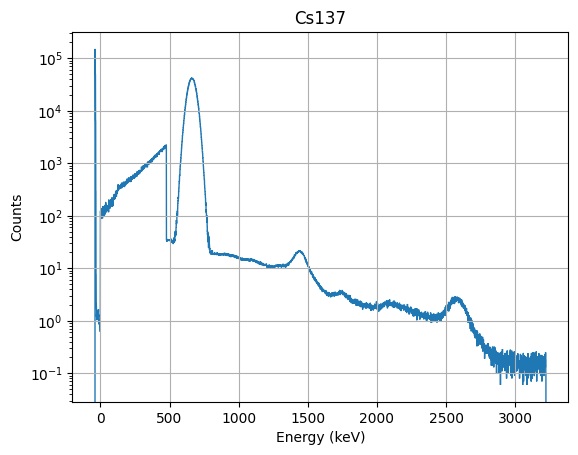

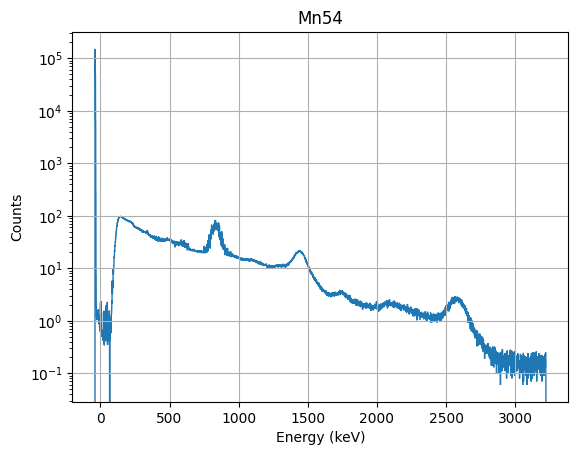

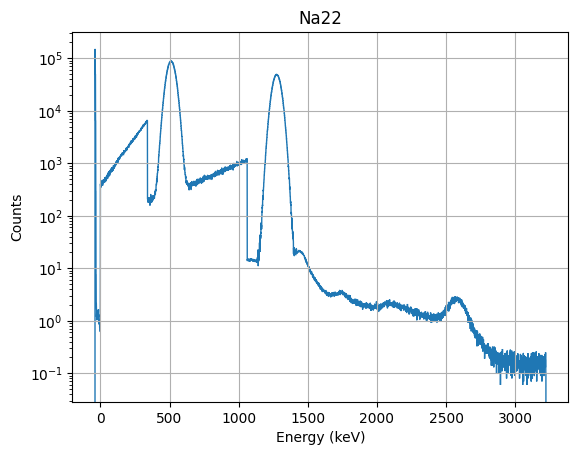

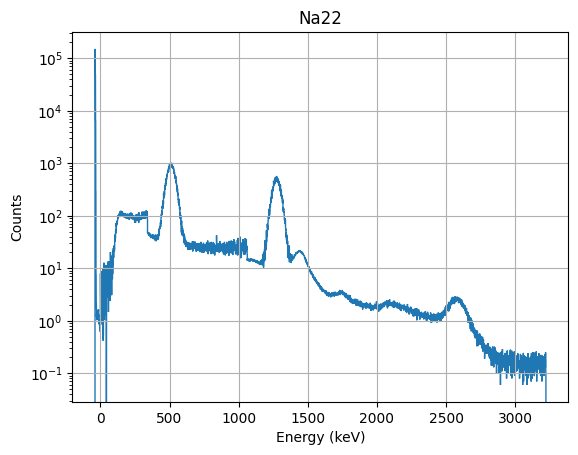

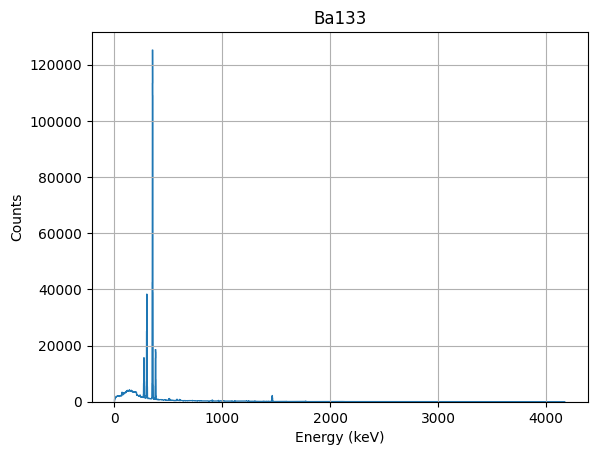

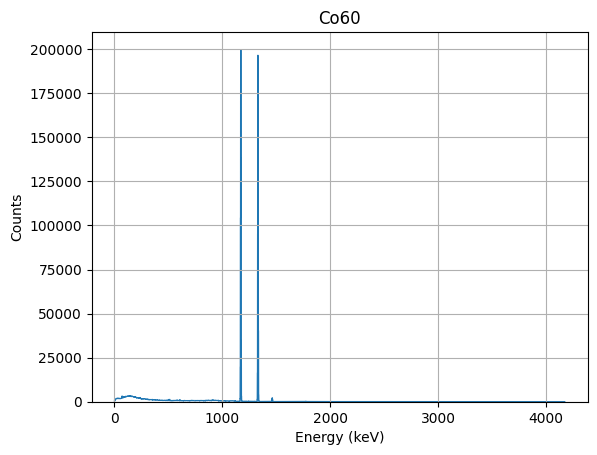

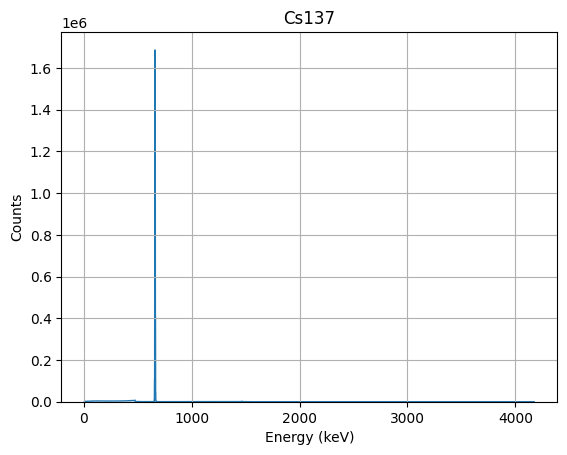

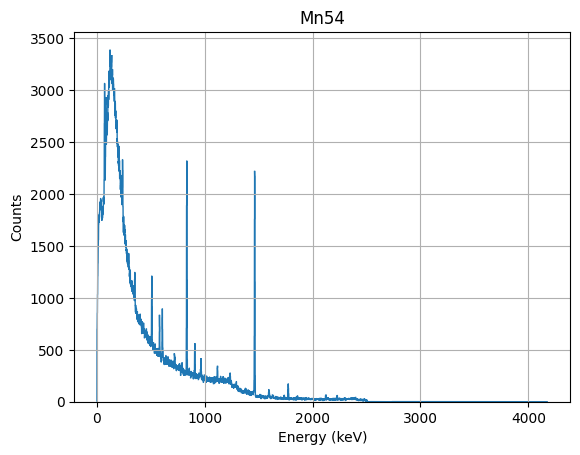

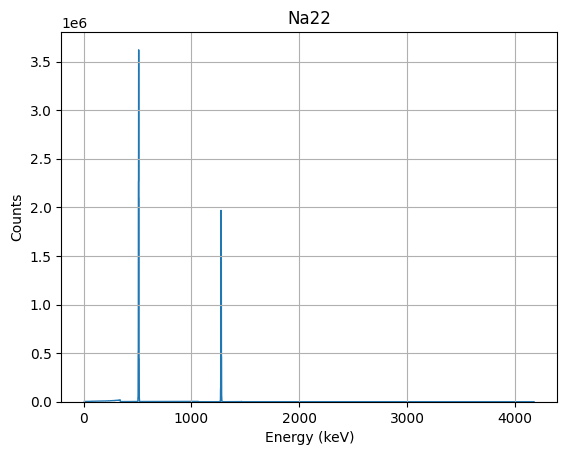

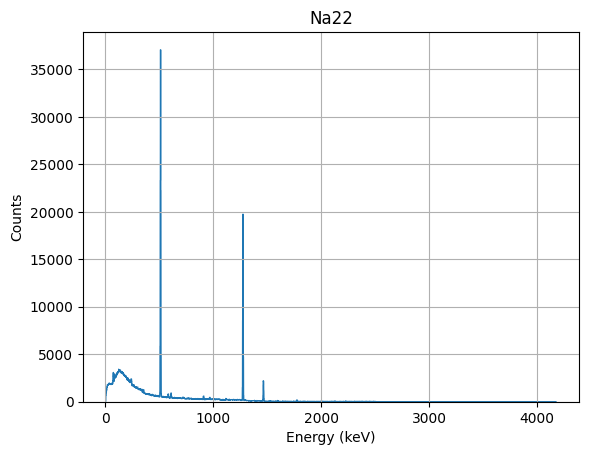

In [6]:
test_cases = [
        ["NaI", co60, 1.0],
        ["NaI", cs137, 10.0],
        ["NaI", mn54, 0.01],
        ["NaI", na22, 10.0],
        ["NaI", na22, 0.1],
        ["HPGe", ba133, 1.0],
        ["HPGe", co60, 1.0],
        ["HPGe", cs137, 10.0],
        ["HPGe", mn54, 0.01],
        ["HPGe", na22, 10.0],
        ["HPGe", na22, 0.1],
    ]

for detector_type, nuclide, signal_to_background_ratio in test_cases:
    print(f"\nTesting {detector_type} with {nuclide.name} at S/B={signal_to_background_ratio}")
    test_get_peaks(detector_type, nuclide, signal_to_background_ratio)